# Q1 · TS-1 Frequency and bandwidth trade

**Question:** which center frequency lets us see a lava-tube roof at `roof_depth_max` with an antenna we can fly?

Lower frequency → less attenuation (deeper) but a longer antenna and coarser resolution.

**Sweep settings** (below) belong to this analysis. **Design values** come from the register.

In [1]:
# Setup — run this first. Finds the repo on your computer; in Google Colab it asks
# which GitHub repo to load and clones it.
import sys, pathlib, subprocess

def _find_repo():
    for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (d / "params" / "variables.yaml").exists():
            return d
    return None

ROOT = _find_repo()
if ROOT is None and "google.colab" in sys.modules:
    repo = input("GitHub repo to load (owner/name): ").strip()
    subprocess.run(["git", "clone", "--depth", "1", f"https://github.com/{repo}.git", "/content/repo"], check=True)
    ROOT = pathlib.Path("/content/repo")
if ROOT is None:
    raise RuntimeError("Open this notebook from inside the repo folder, or in Google Colab.")
sys.path.insert(0, str(ROOT))
print("Repo found ✓")

Repo found ✓


In [2]:
from hs3gpr.params import load
from hs3gpr import budget
import numpy as np

p = load()

# --- analysis settings (not design values) ---
FREQS_MHZ = [5, 10, 15, 20, 30, 40, 60]
FRACTIONAL_BW = 0.4      # bandwidth as a fraction of f0 (sounders are usually ≤ 0.5)
MAX_BW = 20e6            # cap on bandwidth, Hz

def design_point(f0, tan_d):
    bw = min(FRACTIONAL_BW * f0, MAX_BW)
    return p.with_values(f_center=f0, bandwidth=bw, antenna_length=budget.wavelength(f0) / 2,
                         tan_delta_basalt=tan_d)

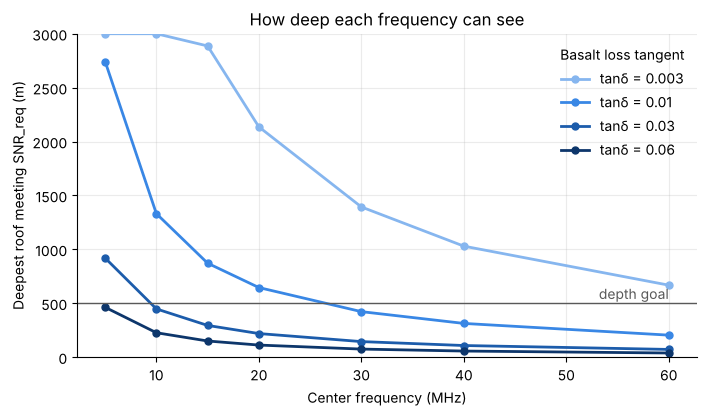

In [3]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 4.2), "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
RAMP = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]   # one blue, light → dark, for ordered values

fig, ax = plt.subplots()
for color, tan_d in zip(RAMP, p["tan_delta_sweep"]):
    depth = [budget.max_detectable_depth(design_point(f * 1e6, tan_d)) for f in FREQS_MHZ]
    ax.plot(FREQS_MHZ, depth, "-o", color=color, lw=2, ms=5, label=f"tanδ = {tan_d:g}")
ax.axhline(p["roof_depth_max"], color="0.35", lw=1)
ax.text(FREQS_MHZ[-1], p["roof_depth_max"] + 40, "depth goal", ha="right", color="0.35")
ax.set(xlabel="Center frequency (MHz)", ylabel="Deepest roof meeting SNR_req (m)",
       title="How deep each frequency can see", ylim=(0, 3000))
ax.legend(title="Basalt loss tangent", frameon=False)
plt.show()

### The cost side: antenna length and resolution

In [4]:
print(f"{'f0 (MHz)':>9} {'B (MHz)':>8} {'half-wave dipole (m)':>21} {'δz in basalt (m)':>17} "
      f"{'depth @ tanδ=' + str(p['tan_delta_basalt']):>18}")
for f in FREQS_MHZ:
    q = design_point(f * 1e6, p["tan_delta_basalt"])
    print(f"{f:>9} {q['bandwidth']/1e6:>8.1f} {q['antenna_length']:>21.1f} "
          f"{budget.vertical_resolution(q['bandwidth'], q['eps_basalt']):>17.1f} "
          f"{budget.max_detectable_depth(q):>18.0f}")

 f0 (MHz)  B (MHz)  half-wave dipole (m)  δz in basalt (m)  depth @ tanδ=0.01
        5      2.0                  30.0              28.3               2742
       10      4.0                  15.0              14.2               1331
       15      6.0                  10.0               9.4                871
       20      8.0                   7.5               7.1                645
       30     12.0                   5.0               4.7                422
       40     16.0                   3.7               3.5                313
       60     20.0                   2.5               2.8                204


**Record the outcome** in [`q1-baseline/2-trades/TS-1-frequency-bandwidth.md`](../2-trades/TS-1-frequency-bandwidth.md), then write the decision in `docs/decisions/` and update `f_center`, `bandwidth` and `antenna_length` in the register (status `derived`, source `TS-1`).